# Static and dynamic population tuning curves

This notebook compares the matched natural-image and natural-video stimuli in the `natraster` files. For each condition it:

1. averages every channel inside a configurable time window;
2. averages across channels to obtain one population response per stimulus;
3. ranks stimuli independently in the static and dynamic conditions;
4. computes the population Spearman rank correlation across matched stimuli; and
5. computes the same rank correlation separately for every channel and plots its distribution.

Choose `static_response` below to analyze the standard last-frame image, the 2000 ms frame, or the 2250 ms frame. The static and dynamic neural-response windows remain independently configurable. Setting `dynamic_window_ms=None` automatically shifts the static window to the selected frame's time in the movie.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display
from scipy.stats import rankdata


# Locate the repository whether the notebook starts in the project root or scripts/.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "config.yaml").is_file()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path

from project_specific_utils import (
    load_natraster,
    match_timed_static_movie_rasters,
    rowwise_similarity,
    window_mean_responses,
)

## Configuration

`static_response` accepts `"last_frame"`, `"2000ms"`, or `"2250ms"`. Time windows are half-open: `(start_ms, end_ms)` includes the start and excludes the end. Set `dynamic_window_ms=None` to align the dynamic window automatically to the selected frame, or provide a tuple to override it. `good_channels` uses one-based MATLAB channel numbers with both endpoints included; set it to `None` to use every channel. When `use_reliable_channels=True`, this range is intersected with the reliability list selected by `reliable_channels_key` (the static experiment by default).

In [26]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27"#  "red_20260726to27" # 
    dynamic_exp_name: str = "baby1_260716to24" #  "red_20260720to24" #
    # Options: "last_frame", "2000ms", or "2250ms".
    static_response: str = "last_frame"
    good_channels: tuple[int, int] | None = (84, 186) #None #  (101, 109) # 
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None

    source_fs: float = 1000
    static_window_ms: tuple[float, float] = (100, 500)
    # Use None to shift static_window_ms to the chosen movie-frame time.
    # A tuple overrides automatic alignment, e.g. (60, 200) from movie onset.
    dynamic_window_ms: tuple[float, float] | None = (2500, 2900)

    correlation_bin_count: int = 20
    ranked_stimuli_to_show: int = 15
    figure_dpi: int = 120
# EOC


cfg = Cfg()
frame_time_ms_by_static_response = {
    "last_frame": 2500,
    "2000ms": 2000,
    "2250ms": 2250,
}
if cfg.static_response not in frame_time_ms_by_static_response:
    raise ValueError(
        "static_response must be 'last_frame', '2000ms', or '2250ms'."
    )
# end if invalid static_response

selected_frame_time_ms = frame_time_ms_by_static_response[
    cfg.static_response
]
if cfg.dynamic_window_ms is None:
    analysis_dynamic_window_ms = tuple(
        selected_frame_time_ms + time_ms
        for time_ms in cfg.static_window_ms
    )
else:
    analysis_dynamic_window_ms = cfg.dynamic_window_ms
# end if cfg.dynamic_window_ms is None

plt.rcParams["figure.dpi"] = cfg.figure_dpi
cfg

Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', static_response='last_frame', good_channels=(84, 186), use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_fs=1000, static_window_ms=(100, 500), dynamic_window_ms=(2500, 2900), correlation_bin_count=20, ranked_stimuli_to_show=15, figure_dpi=120)

## Load and align the natraster responses

The loader first applies `good_channels` and optionally intersects that range with the static-session reliability list. The same retained physical channels are loaded from both sessions. It then aligns the standard `img_`, `img_2000ms_`, `img_2250ms_`, and `vid_` conditions by the identity that follows their prefix. `cfg.static_response` selects one aligned static condition. Static order is preserved, and stimuli missing from any of the four conditions are removed.

In [27]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"

# By default, use the reliability list estimated from the static session.
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

# Apply the identical physical-channel selection to both sessions.
loaded_static, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError(
        "Static and dynamic sessions retained different physical channels."
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

(
    last_frame_rasters,
    dynamic_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)

static_rasters_by_response = {
    "last_frame": last_frame_rasters,
    "2000ms": image_2000ms_rasters,
    "2250ms": image_2250ms_rasters,
}
static_names_by_response = {
    "last_frame": aligned_names["image"],
    "2000ms": aligned_names["image_2000ms"],
    "2250ms": aligned_names["image_2250ms"],
}
static_rasters = static_rasters_by_response[cfg.static_response]
selected_static_names = static_names_by_response[cfg.static_response]

if static_rasters.shape[0] != dynamic_rasters.shape[0]:
    raise ValueError(
        "Static and dynamic sessions must contain the same physical channels."
    )
# end if channel counts differ

print(f"Static natraster:  {static_path}")
print(f"Dynamic natraster: {dynamic_path}")
print(f"Reliable-channel filter: {cfg.use_reliable_channels}")
if cfg.use_reliable_channels:
    print(f"Reliability config: {reliable_channels_config}")
    print(f"Reliability key: {reliable_channels_key}")
# end if cfg.use_reliable_channels
print(
    f"Selected static response: {cfg.static_response} "
    f"({selected_frame_time_ms:g} ms movie frame)"
)
print(
    "First aligned pair:", selected_static_names[0],
    "<->", aligned_names["movie"][0],
)
print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected MATLAB channels: {channel_numbers.tolist()}")
print(f"Selected channel count: {len(channel_numbers)}")
print("Static shape: ", static_rasters.shape, "(channels, time, stimuli)")
print("Dynamic shape:", dynamic_rasters.shape, "(channels, time, stimuli)")

Static natraster:  /Users/tizianocausin/sd_local/data/baby1_260718to27_natraster_img.mat
Dynamic natraster: /Users/tizianocausin/sd_local/data/baby1_260716to24_natraster_vid.mat
Reliable-channel filter: True
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: baby1_260718to27
Selected static response: last_frame (2500 ms movie frame)
First aligned pair: img_0_0_41171.jpg <-> vid_0_0_41171.mp4
Matched stimuli: 100
Selected MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]
Selected channel count: 30
Static shape:  (30, 1000, 100) (channels, time, stimuli)
Dynamic shape: (30, 3500, 100) (channels, time, stimuli)


## Window-average the responses and compute rank agreement

For each stimulus, the population response is the mean of all selected channels after time averaging. Population Spearman correlation is computed across matched stimuli. Channel-wise Spearman correlations use each channel's own static and dynamic stimulus tuning vectors.

In [28]:
static_channel_responses, static_sample_window = window_mean_responses(
    static_rasters, cfg.static_window_ms, cfg.source_fs,
)
dynamic_channel_responses, dynamic_sample_window = window_mean_responses(
    dynamic_rasters, analysis_dynamic_window_ms, cfg.source_fs,
)

# Mean over channels leaves one activity value for every matched stimulus.
static_population_responses = static_channel_responses.mean(axis=0)
dynamic_population_responses = dynamic_channel_responses.mean(axis=0)

population_rank_correlation = rowwise_similarity(
    static_population_responses[np.newaxis, :],
    dynamic_population_responses[np.newaxis, :],
    metric="spearman",
)[0]
channel_rank_correlations = rowwise_similarity(
    static_channel_responses,
    dynamic_channel_responses,
    metric="spearman",
)

# Rank 1 is the most active stimulus; tied activities receive average ranks.
static_population_ranks = rankdata(
    -static_population_responses, method="average",
)
dynamic_population_ranks = rankdata(
    -dynamic_population_responses, method="average",
)
static_ranking = np.argsort(-static_population_responses, kind="stable")
dynamic_ranking = np.argsort(-dynamic_population_responses, kind="stable")
valid_channel_correlations = np.isfinite(channel_rank_correlations)

print(
    f"Static window:  {cfg.static_window_ms} ms -> samples "
    f"{static_sample_window[0]}:{static_sample_window[1]}"
)
print(
    f"Dynamic window: {analysis_dynamic_window_ms} ms -> samples "
    f"{dynamic_sample_window[0]}:{dynamic_sample_window[1]}"
)
print(f"Population Spearman rho: {population_rank_correlation:.3f}")
print(
    f"Finite channel correlations: {valid_channel_correlations.sum()} / "
    f"{len(channel_rank_correlations)}"
)

Static window:  (100, 500) ms -> samples 100:500
Dynamic window: (2500, 2900) ms -> samples 2500:2900
Population Spearman rho: 0.857
Finite channel correlations: 30 / 30


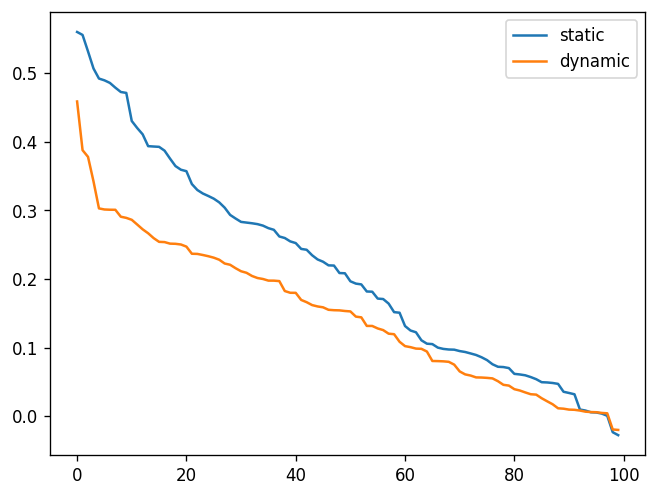

In [29]:
plt.plot(static_population_responses[static_ranking], label="static")
plt.plot(dynamic_population_responses[dynamic_ranking], label="dynamic")
plt.legend()

## Population tuning curves

Each panel uses its condition's own descending stimulus order. Therefore, the x-axis describes preference rank within that condition rather than a shared stimulus order.

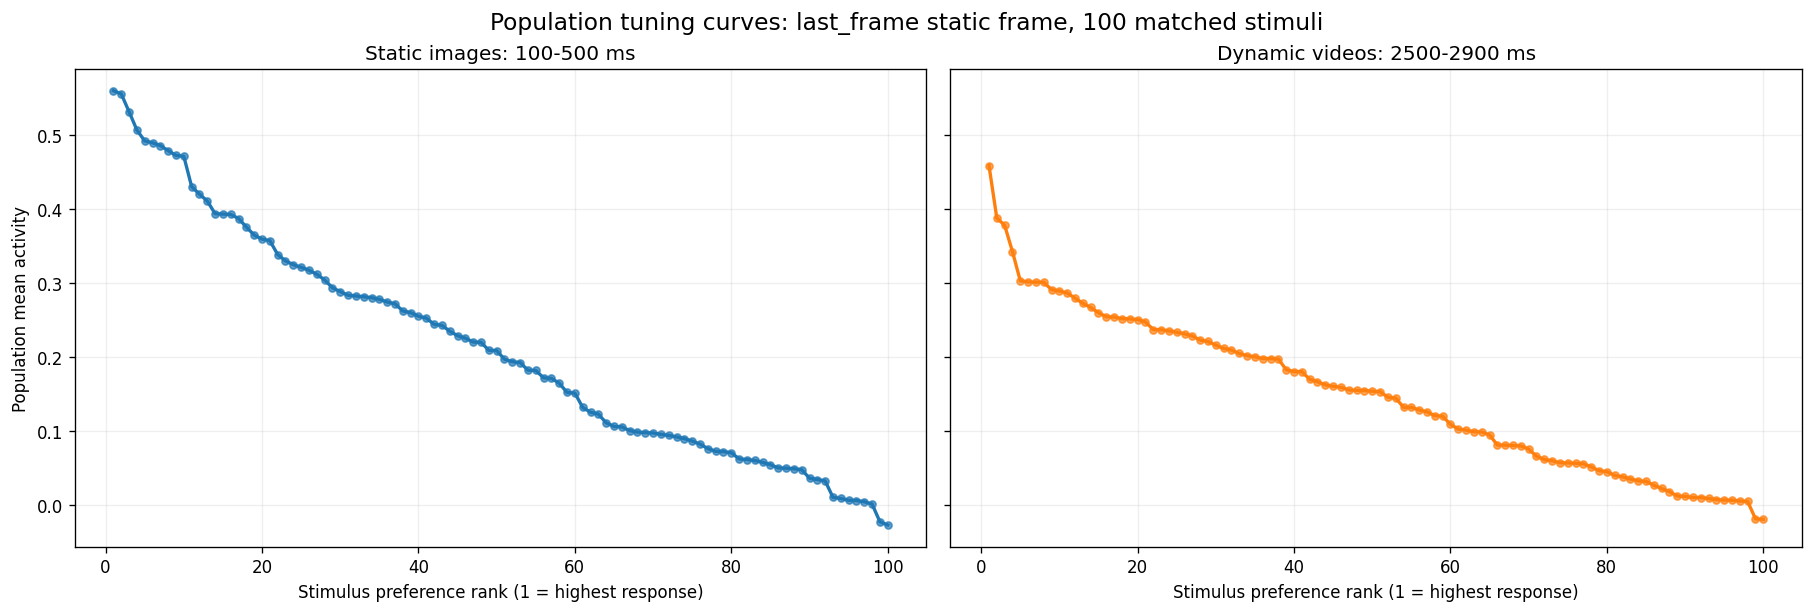

In [30]:
figure, axes = plt.subplots(
    1, 2, figsize=(15, 5), sharey=True, constrained_layout=True,
)
rank_axis = np.arange(1, len(shared_stimuli) + 1)
condition_specs = (
    (
        axes[0], static_population_responses, static_ranking,
        "tab:blue", "Static images", cfg.static_window_ms,
    ),
    (
        axes[1], dynamic_population_responses, dynamic_ranking,
        "tab:orange", "Dynamic videos", analysis_dynamic_window_ms,
    ),
)
for axis, responses, ranking, color, condition, window_ms in condition_specs:
    ranked_responses = responses[ranking]
    axis.plot(rank_axis, ranked_responses, color=color, linewidth=2)
    axis.scatter(rank_axis, ranked_responses, color=color, s=18, alpha=0.7)
    axis.set(
        title=f"{condition}: {window_ms[0]:g}-{window_ms[1]:g} ms",
        xlabel="Stimulus preference rank (1 = highest response)",
    )
    axis.grid(alpha=0.2)
# end for condition specification
axes[0].set_ylabel("Population mean activity")
figure.suptitle(
    f"Population tuning curves: {cfg.static_response} static frame, "
    f"{len(shared_stimuli)} matched stimuli",
    fontsize=14,
)
plt.show()

In [31]:
# Show the leading identities while retaining the complete order in the
# static_ranking and dynamic_ranking arrays for downstream inspection.
shown_stimulus_count = min(
    cfg.ranked_stimuli_to_show, len(shared_stimuli),
)
table_lines = [
    "| Rank | Static stimulus | Static activity | Dynamic stimulus | Dynamic activity |",
    "|---:|:---|---:|:---|---:|",
]
for rank_index in range(shown_stimulus_count):
    static_index = static_ranking[rank_index]
    dynamic_index = dynamic_ranking[rank_index]
    table_lines.append(
        f"| {rank_index + 1} | {shared_stimuli[static_index]} | "
        f"{static_population_responses[static_index]:.3f} | "
        f"{shared_stimuli[dynamic_index]} | "
        f"{dynamic_population_responses[dynamic_index]:.3f} |"
    )
# end for rank_index
display(Markdown("\n".join(table_lines)))

| Rank | Static stimulus | Static activity | Dynamic stimulus | Dynamic activity |
|---:|:---|---:|:---|---:|
| 1 | this_is_how_monkey_eat3 | 0.560 | this_is_how_monkey_eat3 | 0.459 |
| 2 | forest_of_golden_monkeys1 | 0.556 | monkeys_n_apes1 | 0.388 |
| 3 | hilarious_monkeys1 | 0.532 | IMG_46721 | 0.378 |
| 4 | majestic_wildlife_4k3 | 0.507 | king_macaque1 | 0.342 |
| 5 | amazon_jungle1 | 0.492 | monkeys_n_apes11 | 0.303 |
| 6 | monkeys_n_apes7 | 0.490 | hunter_animals1 | 0.301 |
| 7 | IMG_46721 | 0.486 | monkeys_n_apes7 | 0.301 |
| 8 | 43.81_41411 | 0.479 | monkeys_n_apes10 | 0.301 |
| 9 | bandaro3 | 0.473 | this_is_how_monkey_eat2 | 0.291 |
| 10 | monkeys_n_apes1 | 0.471 | greatest_fights1 | 0.289 |
| 11 | these_cats_are_too_funny2 | 0.430 | forest_of_golden_monkeys1 | 0.286 |
| 12 | 4_5_41241 | 0.420 | hilarious_monkeys1 | 0.279 |
| 13 | cute_dogs_collection3 | 0.411 | how_500_monkeys1 | 0.272 |
| 14 | 0_0_41171 | 0.394 | monkey_uses_both_hands_and_feet3 | 0.267 |
| 15 | monkeys_hand1 | 0.393 | these_cats_are_too_funny8 | 0.260 |

## Population static-dynamic agreement

The left plot compares absolute population activity and draws the raw-response identity line. The right plot compares preference ranks directly; points on its identity line have exactly the same rank in both conditions. Spearman $\rho$ summarizes the monotonic rank agreement, not agreement in absolute response magnitude.

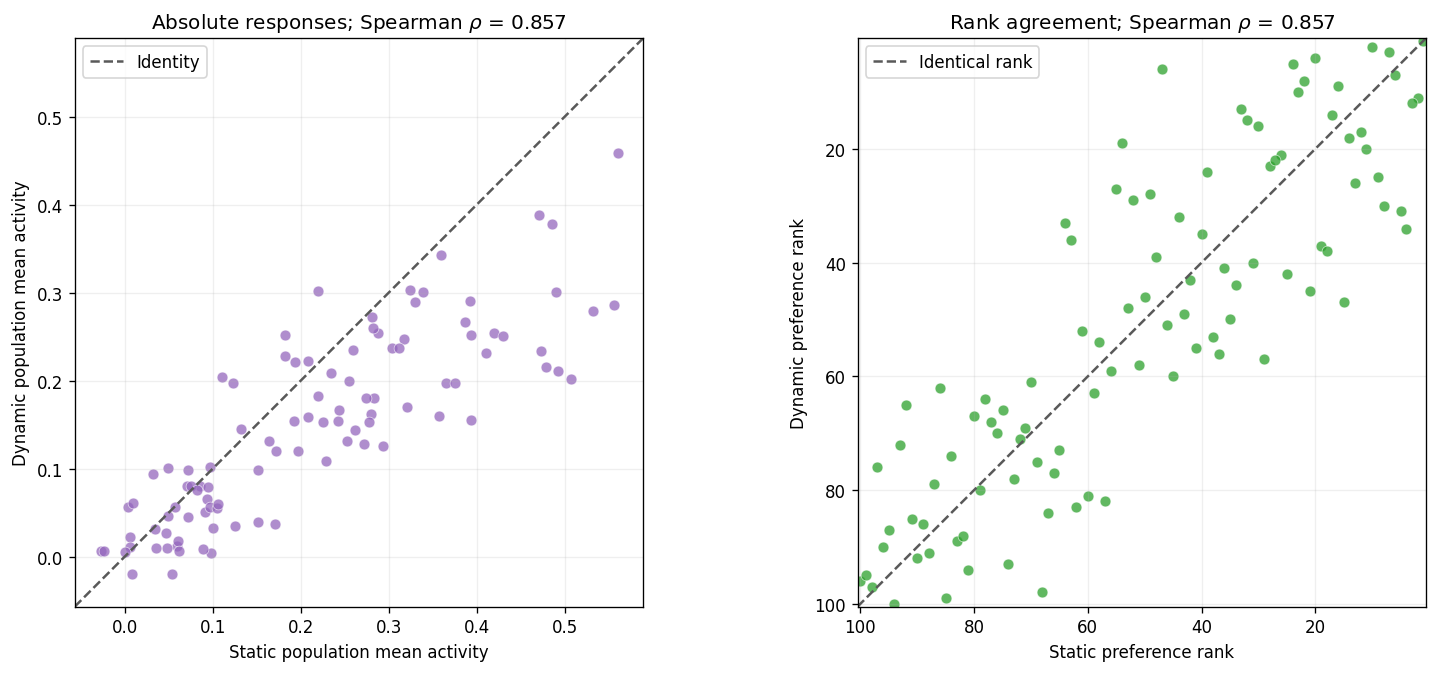

In [32]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

# Absolute activity agreement.
axes[0].scatter(
    static_population_responses, dynamic_population_responses,
    color="tab:purple", s=42, alpha=0.75, edgecolor="white", linewidth=0.4,
)
activity_min = min(
    static_population_responses.min(), dynamic_population_responses.min(),
)
activity_max = max(
    static_population_responses.max(), dynamic_population_responses.max(),
)
activity_padding = 0.05 * max(activity_max - activity_min, 1e-12)
activity_limits = (activity_min - activity_padding, activity_max + activity_padding)
axes[0].plot(
    activity_limits, activity_limits, "--", color="0.35",
    linewidth=1.5, label="Identity",
)
axes[0].set(
    xlim=activity_limits, ylim=activity_limits, aspect="equal",
    xlabel="Static population mean activity",
    ylabel="Dynamic population mean activity",
    title=f"Absolute responses; Spearman $\\rho$ = {population_rank_correlation:.3f}",
)
axes[0].legend()
axes[0].grid(alpha=0.2)

# Preference-rank agreement. Both axes run from most to least preferred.
axes[1].scatter(
    static_population_ranks, dynamic_population_ranks,
    color="tab:green", s=42, alpha=0.75, edgecolor="white", linewidth=0.4,
)
rank_limits = (0.5, len(shared_stimuli) + 0.5)
axes[1].plot(
    rank_limits, rank_limits, "--", color="0.35",
    linewidth=1.5, label="Identical rank",
)
axes[1].set(
    xlim=rank_limits, ylim=rank_limits, aspect="equal",
    xlabel="Static preference rank",
    ylabel="Dynamic preference rank",
    title=f"Rank agreement; Spearman $\\rho$ = {population_rank_correlation:.3f}",
)
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.show()

## Distribution of channel-wise rank correlations

Each channel contributes one Spearman correlation across the matched stimuli. The histogram height is the number of channels in each correlation interval; the labels above non-empty bars also report the percentage of channels. Channels with constant activity in either condition have undefined rank correlation and are reported but excluded from the histogram.

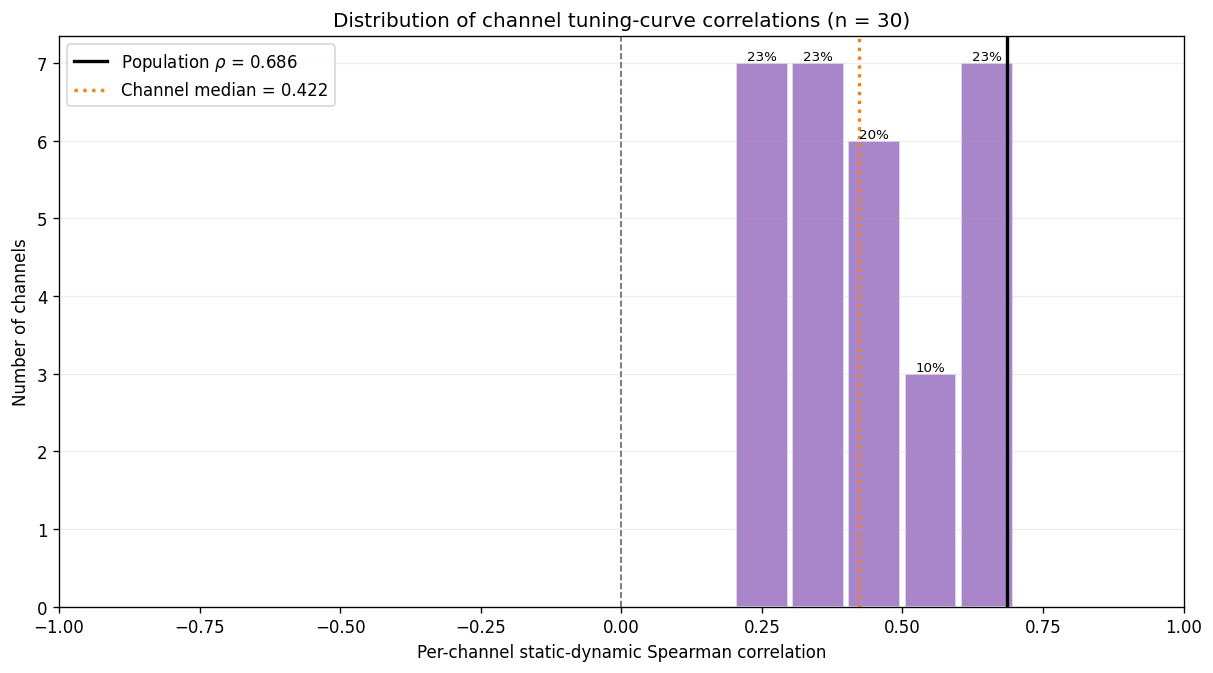

Channel rho summary: mean=0.452, median=0.422, min=0.231, max=0.689
Undefined constant-channel correlations: 0


In [24]:
finite_channel_correlations = channel_rank_correlations[
    valid_channel_correlations
]
correlation_bin_edges = np.linspace(
    -1, 1, cfg.correlation_bin_count + 1,
)
correlation_counts, _ = np.histogram(
    finite_channel_correlations, bins=correlation_bin_edges,
)
correlation_bin_centers = (
    correlation_bin_edges[:-1] + correlation_bin_edges[1:]
) / 2
correlation_bin_widths = np.diff(correlation_bin_edges)

figure, axis = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
bars = axis.bar(
    correlation_bin_centers, correlation_counts,
    width=0.92 * correlation_bin_widths, color="tab:purple",
    alpha=0.8, edgecolor="white",
)
for bar, count in zip(bars, correlation_counts, strict=True):
    if count == 0:
        continue
    # end if empty bin
    percentage = 100 * count / len(finite_channel_correlations)
    axis.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{percentage:.0f}%", ha="center", va="bottom", fontsize=8,
    )
# end for histogram bar
axis.axvline(0, color="0.4", linestyle="--", linewidth=1)
axis.axvline(
    population_rank_correlation, color="black", linewidth=2,
    label=f"Population $\\rho$ = {population_rank_correlation:.3f}",
)
axis.axvline(
    np.median(finite_channel_correlations), color="tab:orange",
    linewidth=2, linestyle=":",
    label=f"Channel median = {np.median(finite_channel_correlations):.3f}",
)
axis.set(
    xlim=(-1, 1), xlabel="Per-channel static-dynamic Spearman correlation",
    ylabel="Number of channels",
    title=(
        f"Distribution of channel tuning-curve correlations "
        f"(n = {len(finite_channel_correlations)})"
    ),
)
axis.legend()
axis.grid(axis="y", alpha=0.2)
plt.show()

print(
    "Channel rho summary: "
    f"mean={finite_channel_correlations.mean():.3f}, "
    f"median={np.median(finite_channel_correlations):.3f}, "
    f"min={finite_channel_correlations.min():.3f}, "
    f"max={finite_channel_correlations.max():.3f}"
)
print(
    f"Undefined constant-channel correlations: "
    f"{(~valid_channel_correlations).sum()}"
)

## Analysis outputs

The cell below collects the numerical results for reuse without recomputing the rankings. The two ranking arrays contain zero-based indices into `shared_stimuli`, in descending population activity.

In [25]:
tuning_results = {
    "static_response": cfg.static_response,
    "selected_frame_time_ms": selected_frame_time_ms,
    "static_window_ms": np.asarray(cfg.static_window_ms),
    "dynamic_window_ms": np.asarray(analysis_dynamic_window_ms),
    "shared_stimuli": np.asarray(shared_stimuli),
    "selected_static_names": np.asarray(selected_static_names),
    "dynamic_names": np.asarray(aligned_names["movie"]),
    "channel_numbers": channel_numbers,
    "static_channel_responses": static_channel_responses,
    "dynamic_channel_responses": dynamic_channel_responses,
    "static_population_responses": static_population_responses,
    "dynamic_population_responses": dynamic_population_responses,
    "static_population_ranks": static_population_ranks,
    "dynamic_population_ranks": dynamic_population_ranks,
    "static_ranking": static_ranking,
    "dynamic_ranking": dynamic_ranking,
    "population_rank_correlation": population_rank_correlation,
    "channel_rank_correlations": channel_rank_correlations,
    "correlation_bin_edges": correlation_bin_edges,
    "correlation_counts": correlation_counts,
}

print("Available tuning_results fields:")
print("\n".join(f"- {name}" for name in tuning_results))

Available tuning_results fields:
- static_response
- selected_frame_time_ms
- static_window_ms
- dynamic_window_ms
- shared_stimuli
- selected_static_names
- dynamic_names
- channel_numbers
- static_channel_responses
- dynamic_channel_responses
- static_population_responses
- dynamic_population_responses
- static_population_ranks
- dynamic_population_ranks
- static_ranking
- dynamic_ranking
- population_rank_correlation
- channel_rank_correlations
- correlation_bin_edges
- correlation_counts
